**Author:** Dr. Alexis Hucteau  
**Contact:** [LinkedIn](https://www.linkedin.com/in/alexis-hucteau/) [Malt](https://www.malt.fr/profile/alexishucteau1)  
**Date:** May 2026

### Licensing Notice
- **Code:** This work is licensed under the [GNU GPL v3](https://www.gnu.org/licenses/gpl-3.0.html).
- **Analysis & Visualizations:** The interpretive content of this notebook is licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).

*Copyright (c) 2026 Alexis Hucteau. All rights reserved.*

In [ ]:
import pandas as pd
import numpy as np

premier_tour = pd.read_parquet('../data/processed/premier_tour_cleaned.parquet')
deuxieme_tour = pd.read_parquet('../data/processed/deuxieme_tour_cleaned.parquet')

# Analyse du premier tour

In [3]:
display(premier_tour.head())

,Tour,bureau,inscrits,abstentions,votants,votants_ap_emargement,blancs,nuls,exprimes,Briançon,...,Meilhac,Piquemal,Pedinotti,adresse,Geo_Point,Geo_Shape,gml_id,infobulle,oid,Nom
0,1,0005,957,401,556,556,4,2,550,121,...,9,208,7,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00<\xa5\x9c\x8e\x81\xff\xf...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.385,Bureau de vote : 005\nLieu de vote : Salle Bar...,385,Salle Barcelone
1,1,0007,892,384,508,508,2,1,505,98,...,2,134,7,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00V\xf3m\r\xae\x1a\xf7?\xf...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.417,Bureau de vote : 007\nLieu de vote : Salle Bar...,417,Salle Barcelone
2,1,0014,1159,513,646,646,3,3,640,165,...,6,245,6,60 rue Matabiau,b'\x01\x01\x00\x00\x00\xe9P\xc9\xe7\xac:\xf7?L...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.516,Bureau de vote : 014\nLieu de vote : École élé...,516,École élémentaire Bayard
3,1,0017,1131,362,769,769,3,1,765,223,...,10,229,10,60 rue Matabiau,b'\x01\x01\x00\x00\x00\xd8)\xe8G\xf8&\xf7?\xb8...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.486,Bureau de vote : 017\nLieu de vote : École élé...,486,École élémentaire Bayard
4,1,0018,781,328,453,453,4,2,447,126,...,8,122,4,6 rue du Lieutenant Colonnel Pélissier,b'\x01\x01\x00\x00\x00\xff\xf2^\xebH:\xf7?\xcf...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.463,Bureau de vote : 018\nLieu de vote : Salle Osè...,463,Salle Osète


In [4]:
emargement = premier_tour['votants'] == premier_tour['votants_ap_emargement']

emargement.value_counts()

display(premier_tour.loc[~emargement, ['bureau', 'votants', 'votants_ap_emargement']])


,bureau,votants,votants_ap_emargement
7,0029,730,731
13,0060,669,668
62,0022,620,621
63,0023,636,635
70,0048,791,790
74,0079,701,697
93,0167,553,552
96,0209,603,604
97,0210,677,676
106,0240,428,429


Text(0.5, 1.0, 'Taux de participation au premier Tour à travers les différents bureaux de vote')

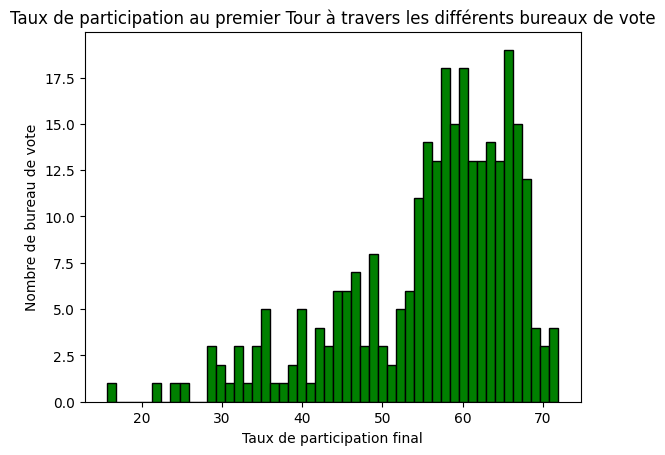

In [5]:
import matplotlib.pyplot as plt

premier_tour['tx_participation'] = (premier_tour['votants'] / premier_tour['inscrits'])*100
n, bins, patches = plt.hist(premier_tour['tx_participation'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de participation final')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de participation au premier Tour à travers les différents bureaux de vote')

Text(0.5, 1.0, 'Taux de votes blancs et nuls au premier Tour à travers les différents bureaux de vote')

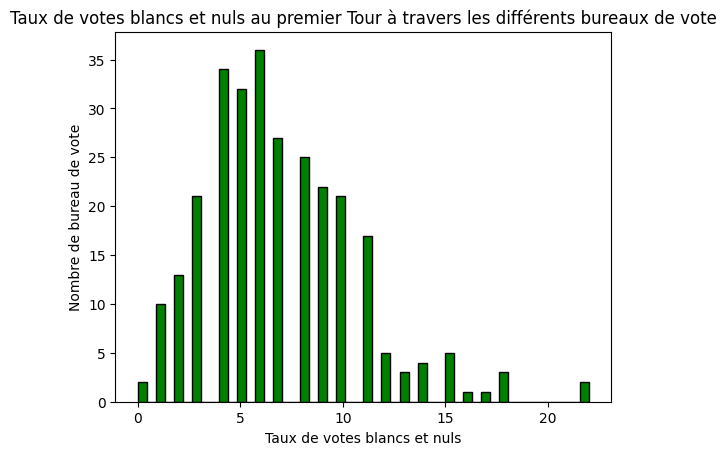

In [17]:
premier_tour['tx_nuls_blc'] = premier_tour['blancs'] + premier_tour['nuls']
n, bins, patches = plt.hist(premier_tour['tx_nuls_blc'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de votes blancs et nuls')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de votes blancs et nuls au premier Tour à travers les différents bureaux de vote')

In [84]:
votants_premier_tour = premier_tour['exprimes'].sum()

scores_vivre_mieux = [(premier_tour['Briançon'] / premier_tour['votants']) *100, premier_tour['Briançon']]
scores_NPA = [(premier_tour['Scalli'] / premier_tour['votants']) *100, premier_tour['Scalli']]
scores_Lutte = [(premier_tour['Adrada'] / premier_tour['votants']) *100, premier_tour['Adrada']]
scores_TRAVAILLEURS  = [(premier_tour['Menendez'] / premier_tour['votants']) *100, premier_tour['Menendez']]
scores_RN = [(premier_tour['Leonardelli'] / premier_tour['votants']) *100, premier_tour['Leonardelli']]
scores_RECONQUETE  = [(premier_tour['Cottrel'] / premier_tour['votants']) *100, premier_tour['Cottrel']]
scores_NOUVEL_AIR = [(premier_tour['Meilhac'] / premier_tour['votants']) *100, premier_tour['Meilhac']]
scores_RV = [(premier_tour['Pedinotti'] / premier_tour['votants']) *100, premier_tour['Pedinotti']]
scores_Moudenc = [(premier_tour['Moudenc'] / premier_tour['votants']) *100, premier_tour['Moudenc']]
scores_Piquemal = [(premier_tour['Piquemal'] / premier_tour['votants']) *100, premier_tour['Piquemal']]

scores_gauche = [scores_vivre_mieux[0] + scores_Piquemal[0] + scores_RV[0] + scores_TRAVAILLEURS[0] + scores_Lutte[0] + scores_NPA[0], 
                 scores_vivre_mieux[1] + scores_Piquemal[1] + scores_RV[1] + scores_TRAVAILLEURS[1] + scores_Lutte[1] + scores_NPA[1]]
scores_union_deuxieme_tour = [scores_vivre_mieux[0] + scores_Piquemal[0], scores_vivre_mieux[1] + scores_Piquemal[1]]
scores_droite = [scores_Moudenc[0] + scores_RN[0] + scores_RECONQUETE[0], scores_Moudenc[1] + scores_RN[1] + scores_RECONQUETE[1]]
scores_premier_tour = {'scores_vivre_mieux' : scores_vivre_mieux, 
                       'scores_RN' : scores_RN,
                        'scores_Moudenc' : scores_Moudenc, 'scores_Piquemal' : scores_Piquemal, 
                        'scores_gauche' : scores_gauche, 'scores_droite' : scores_droite, 'scores_union_deuxieme_tour' : scores_union_deuxieme_tour
}

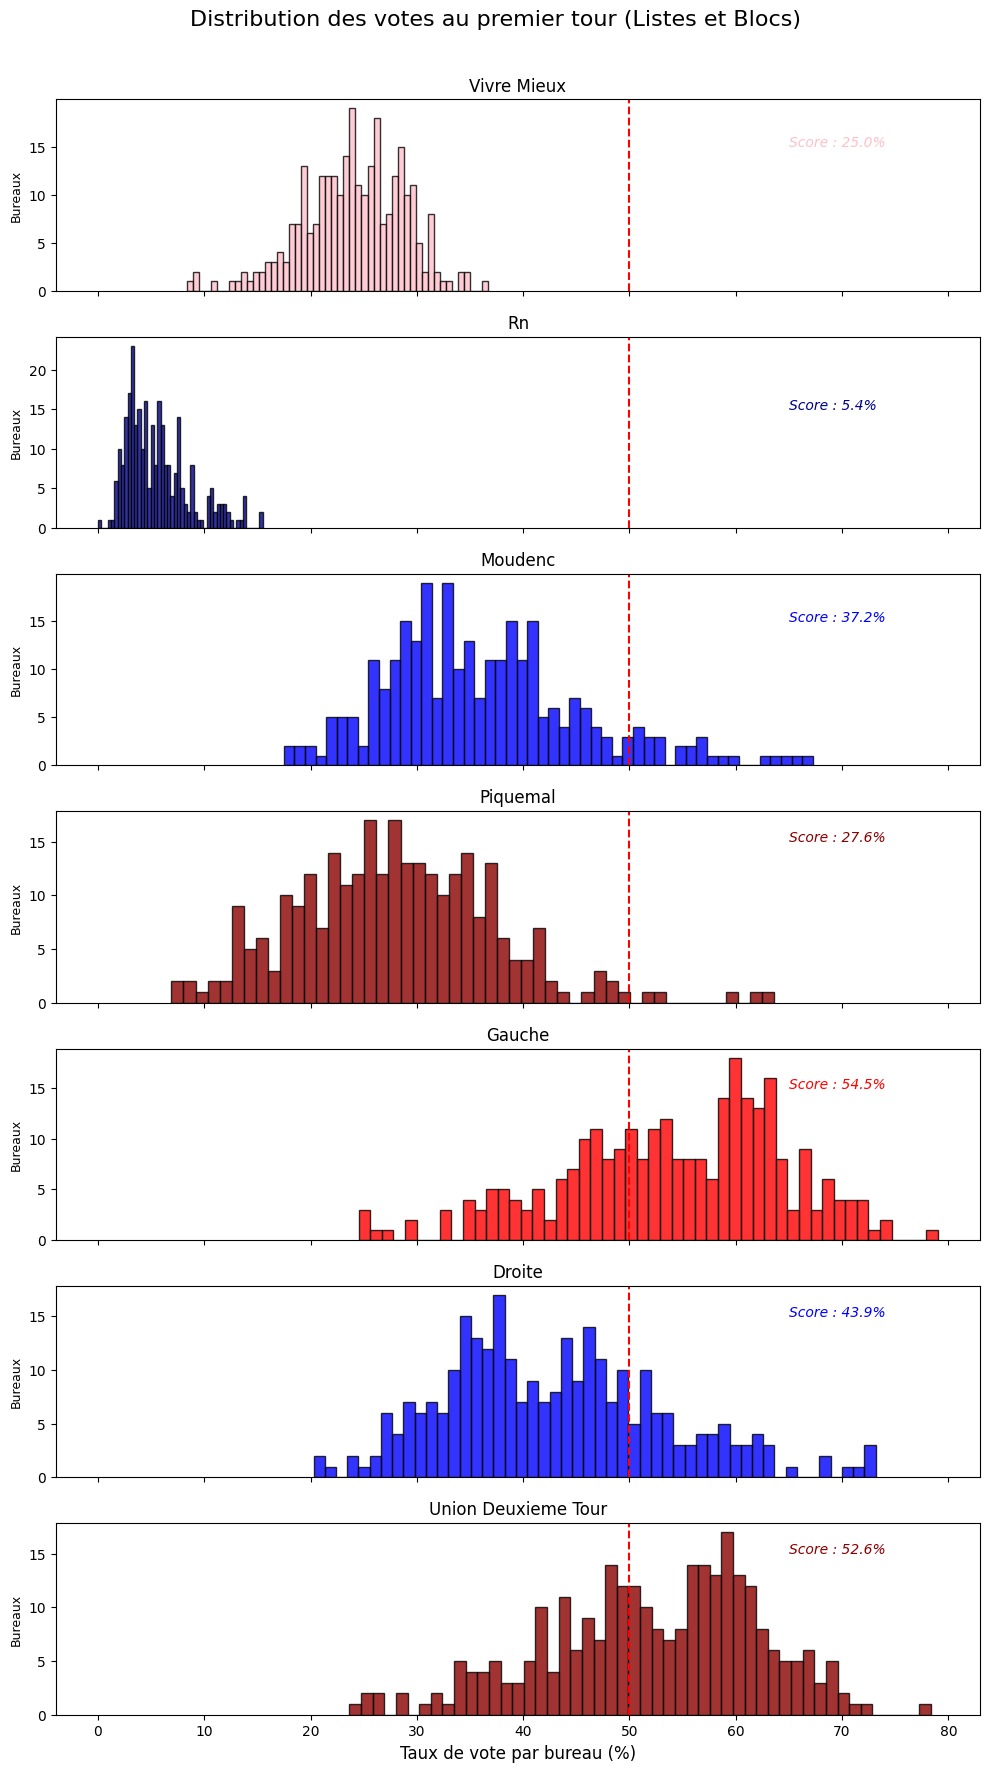

In [85]:
n_graphs = len(scores_premier_tour)

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

colors = ['pink', 'darkblue', 'blue', 'darkred', 'red', 'blue', 'darkred']

for ax, (nom_variable, donnees), color in zip(axes, scores_premier_tour.items(), colors):
    
    ax.hist(donnees[0], bins=50, edgecolor='black', alpha=0.8, facecolor = color)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    score = 100*(donnees[1].sum()) / votants_premier_tour
   
    texte_info = f"Score : {score:.1f}%"
    
    ax.text(x=65, y=15, s=texte_info, 
            fontsize=10, 
            color=color,
            style='italic') 
    
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50%')

axes[-1].set_xlabel('Taux de vote par bureau (%)', fontsize=12)

fig.suptitle('Distribution des votes au premier tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()

plt.show()

# Analyse du Second tour

In [9]:
display(deuxieme_tour.head())

,Tour,bureau,inscrits,abstentions,votants,votants_ap_emargement,blancs,nuls,exprimes,Moudenc,Piquemal,adresse,Geo_Point,Geo_Shape,gml_id,infobulle,oid,Nom
0,2,0002,901,264,637,637,10,3,624,345,279,Place du Capitole,b'\x01\x01\x00\x00\x00\x87Z\xa4&\xee\x16\xf7?*...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.321,Bureau de vote : 002\nLieu de vote : Capitole ...,321,Capitole – Salle des Commissions
1,2,0005,956,335,621,621,15,4,602,292,310,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00<\xa5\x9c\x8e\x81\xff\xf...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.385,Bureau de vote : 005\nLieu de vote : Salle Bar...,385,Salle Barcelone
2,2,0006,925,325,600,600,11,3,586,274,312,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00H\x8e#C\x1e\x0f\xf7?\xbe...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.510,Bureau de vote : 006\nLieu de vote : Salle Bar...,510,Salle Barcelone
3,2,0010,1107,334,773,773,14,6,753,403,350,13 boulevard d'Arcole,b'\x01\x01\x00\x00\x00\xa6\x03\xd8\xad\\\x06\x...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.430,Bureau de vote : 010\nLieu de vote : École élé...,430,École élémentaire du Nord
4,2,0013,1157,401,756,756,10,6,740,346,394,60 rue Matabiau,b'\x01\x01\x00\x00\x00\x90j\x80\x02\xc7.\xf7?8...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.557,Bureau de vote : 013\nLieu de vote : École élé...,557,École élémentaire Bayard


In [10]:
emargement = deuxieme_tour['votants'] == deuxieme_tour['votants_ap_emargement']

emargement.value_counts()

display(deuxieme_tour.loc[~emargement, ['bureau', 'votants', 'votants_ap_emargement']])

,bureau,votants,votants_ap_emargement
18,0057,673,672
20,0060,766,767
46,0204,382,381
53,0238,661,657
54,0239,599,598
63,0001,686,687
64,0003,538,537
77,0053,775,776
94,0136,621,622
95,0138,762,761


Text(0.5, 1.0, 'Taux de participation au deuxième Tour à travers les différents bureaux de vote')

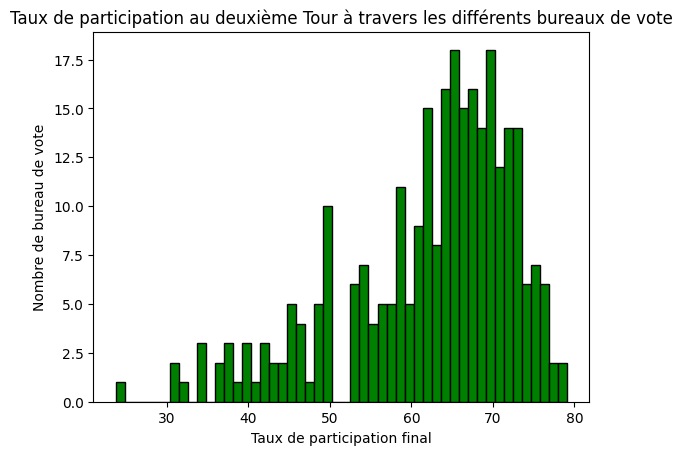

In [11]:
deuxieme_tour['tx_participation'] = (deuxieme_tour['votants'] / deuxieme_tour['inscrits'])*100
n, bins, patches = plt.hist(deuxieme_tour['tx_participation'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de participation final')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de participation au deuxième Tour à travers les différents bureaux de vote')

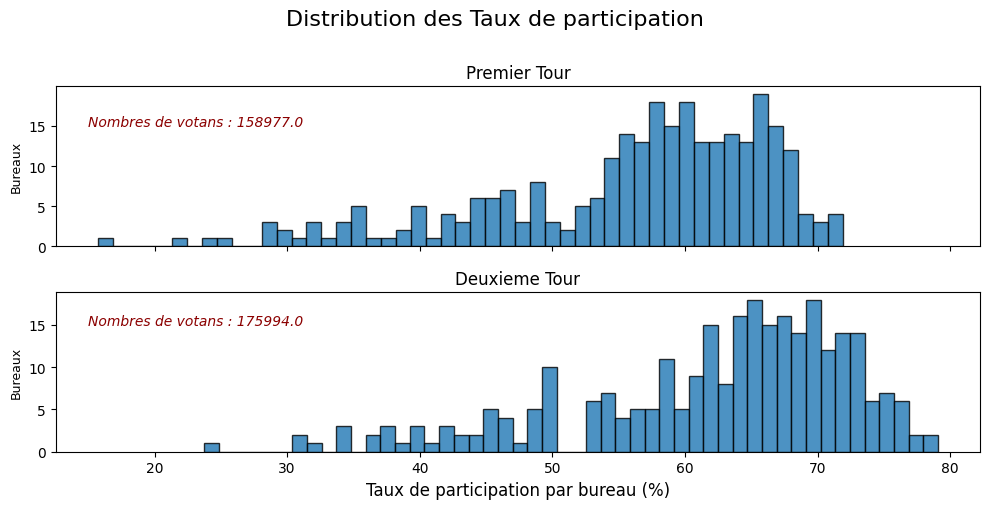

In [57]:
participation_premier = premier_tour['votants'].sum()
participation_deuxieme = deuxieme_tour['votants'].sum()

participation = [participation_premier, participation_deuxieme]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 2.5 * 2), sharex=True)

for ax, (nom_variable, donnees), partic in zip(axes, {'premier_tour' : premier_tour['tx_participation'], 
                                              'deuxieme_tour' : deuxieme_tour['tx_participation']}.items(), participation):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    texte_info = f"Nombres de votans : {partic:.1f}"
    
    ax.text(x=15, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 

    
    
axes[-1].set_xlabel('Taux de participation par bureau (%)', fontsize=12)

fig.suptitle('Distribution des Taux de participation', fontsize=16, y=1.01)

plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Taux de votes blancs et nuls au deuxième Tour à travers les différents bureaux de vote')

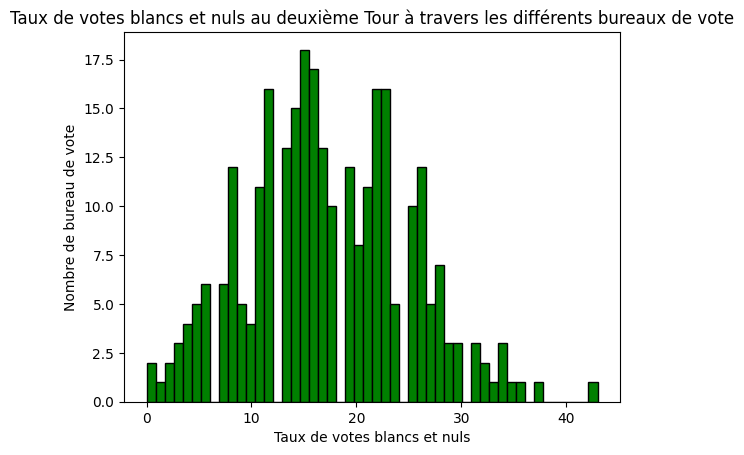

In [18]:
deuxieme_tour['tx_nuls_blc'] = deuxieme_tour['blancs'] + deuxieme_tour['nuls']
n, bins, patches = plt.hist(deuxieme_tour['tx_nuls_blc'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de votes blancs et nuls')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de votes blancs et nuls au deuxième Tour à travers les différents bureaux de vote')

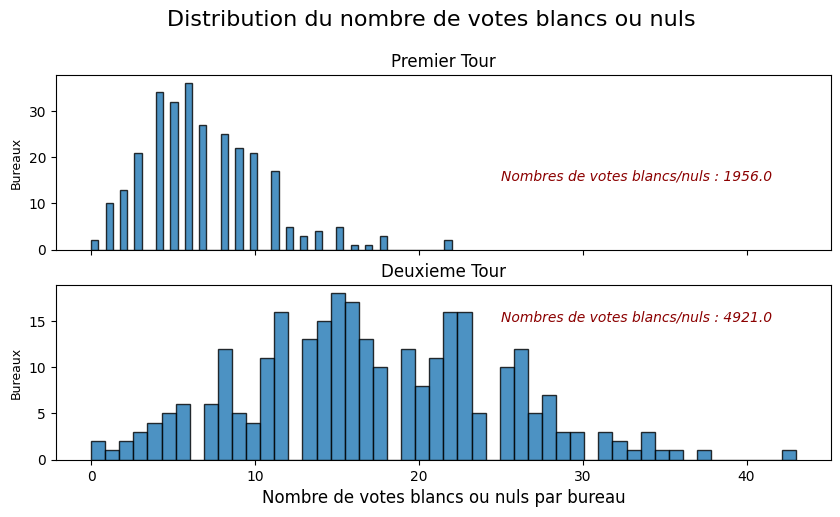

In [ ]:
votes_blancs_nuls_premier = premier_tour['tx_nuls_blc'].sum()
votes_blancs_nuls_deuxieme = deuxieme_tour['tx_nuls_blc'].sum()

votes_blancs_nuls = [votes_blancs_nuls_premier, votes_blancs_nuls_deuxieme]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 2.5 * 2), sharex=True)

for ax, (nom_variable, donnees), votes_blancs in zip(axes, {'premier_tour' : premier_tour['tx_nuls_blc'], 
                                              'deuxieme_tour' : deuxieme_tour['tx_nuls_blc']}.items(), votes_blancs_nuls):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)
    
    texte_info = f"Nombres de votes blancs/nuls : {votes_blancs:.1f}"
    
    ax.text(x=25, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 
    
axes[-1].set_xlabel('Nombre de votes blancs ou nuls par bureau', fontsize=12)

fig.suptitle('Distribution du nombre de votes blancs ou nuls', fontsize=16, y=1.01)

# plt.tight_layout()

plt.show()

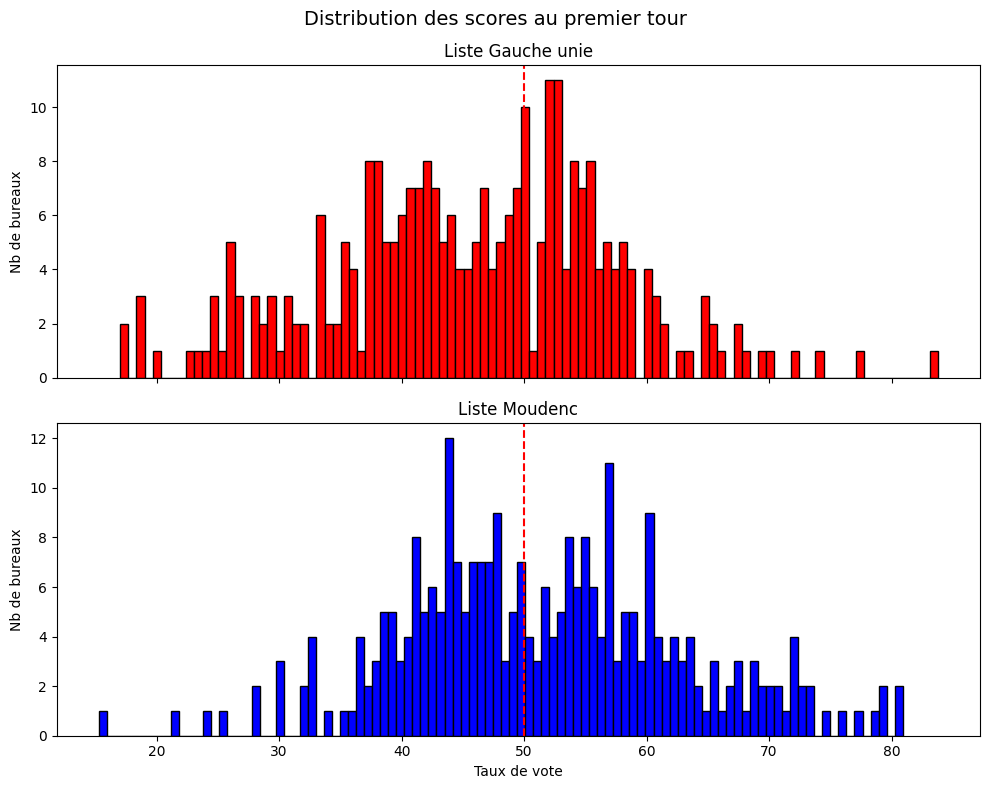

In [ ]:
scores_gauche_unie = [(deuxieme_tour['Piquemal'] / deuxieme_tour['votants']) *100, deuxieme_tour['Piquemal'] ]
scores_Moudenc = [(deuxieme_tour['Moudenc'] / deuxieme_tour['votants']) *100, deuxieme_tour['Moudenc']]

scores = [scores_gauche_unie.sum(), scores_Moudenc.sum()]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

axes[0].hist(scores_gauche_unie, bins=100, edgecolor='black', facecolor='red')
axes[0].set_title('Liste Gauche unie')
axes[0].set_ylabel('Nb de bureaux')

axes[1].hist(scores_Moudenc, bins=100, edgecolor='black', facecolor='blue')
axes[1].set_title('Liste Moudenc')
axes[1].set_ylabel('Nb de bureaux')

texte_info = f"Nombres de votes blancs/nuls : {votes_blancs:.1f}"
    
    ax.text(x=25, y=15, s=texte_info, 
            fontsize=10, 
            color='darkred',
            style='italic') 

axes[1].set_xlabel('Taux de vote')

fig.suptitle('Distribution des scores au premier tour', fontsize=14)
for ax in axes:
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5)
    
plt.tight_layout()
plt.show()

In [86]:
votants_deuxieme_tour = deuxieme_tour['exprimes'].sum()

scores_Moudenc = [(deuxieme_tour['Moudenc'] / deuxieme_tour['votants']) *100, deuxieme_tour['Moudenc']]
scores_Piquemal = [(deuxieme_tour['Piquemal'] / deuxieme_tour['votants']) *100, deuxieme_tour['Piquemal']]

scores_deuxieme_tour = {'scores_Piquemal' : scores_Piquemal,
                        'scores_Moudenc' : scores_Moudenc}

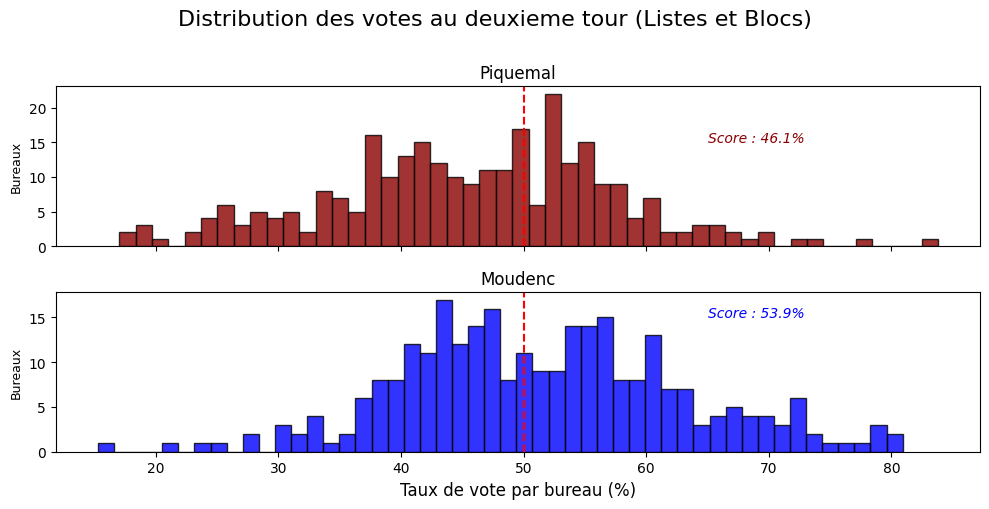

In [87]:
n_graphs = len(scores_deuxieme_tour)

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

colors = ['darkred', 'blue']

for ax, (nom_variable, donnees), color in zip(axes, scores_deuxieme_tour.items(), colors):
    
    ax.hist(donnees[0], bins=50, edgecolor='black', alpha=0.8, facecolor = color)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)

    score = 100*(donnees[1].sum()) / votants_deuxieme_tour
   
    texte_info = f"Score : {score:.1f}%"
    
    ax.text(x=65, y=15, s=texte_info, 
            fontsize=10, 
            color=color,
            style='italic') 
    
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50%')

axes[-1].set_xlabel('Taux de vote par bureau (%)', fontsize=12)

fig.suptitle('Distribution des votes au deuxieme tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()

plt.show()

# Analyse Multivariée et Clustering (Typologie des bureaux)

In [89]:
print(premier_tour.columns)

Index(['Tour', 'bureau', 'inscrits', 'abstentions', 'votants',
       'votants_ap_emargement', 'blancs', 'nuls', 'exprimes', 'Briançon',
       'Scalli', 'Adrada', 'Menendez', 'Moudenc', 'Leonardelli', 'Cottrel',
       'Meilhac', 'Piquemal', 'Pedinotti', 'adresse', 'Geo_Point', 'Geo_Shape',
       'gml_id', 'infobulle', 'oid', 'Nom', 'tx_participation', 'tx_nuls_blc'],
      dtype='str')


In [99]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

liste_bureau = premier_tour['bureau']

df = premier_tour.drop(columns = ['Tour', 'bureau', 'votants', 'votants_ap_emargement', 'adresse', 'Geo_Point', 'Geo_Shape',
       'gml_id', 'infobulle', 'oid', 'Nom', 'tx_participation', 'tx_nuls_blc', 'exprimes'])

df['blc_nuls'] = df['blancs'] + df['nuls']

df = df.drop(columns=['blancs', 'nuls'])

listes_candidates = df.columns[1:]

df[listes_candidates] = df[listes_candidates].div(df['inscrits'], axis=0) * 100

df = df.drop(columns=['inscrits'])

Variance expliquée par axe : [24.57812458 19.68322513]


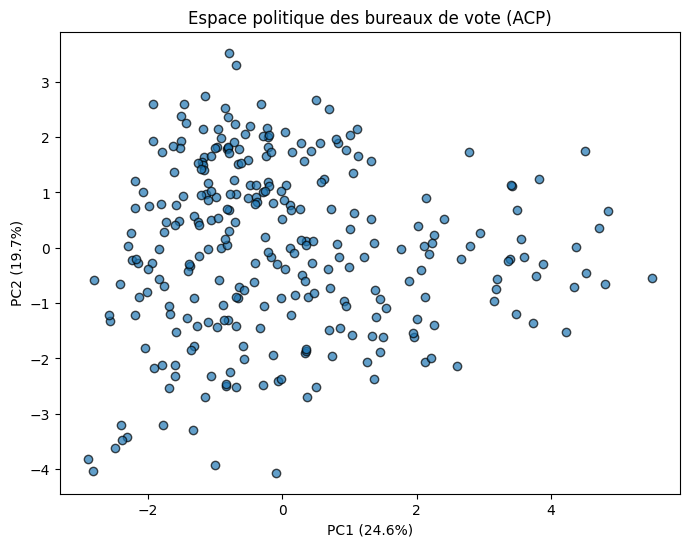

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par axe : {pca.explained_variance_ratio_ * 100}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Espace politique des bureaux de vote (ACP)')
plt.show()

In [104]:
colonnes_totales = df.columns

df_loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=colonnes_totales  
)

print("--- Contributions à l'axe PC1 ---")
display(df_loadings.sort_values(by='PC1', ascending=False)['PC1'])

print("\n--- Contributions à l'axe PC2 ---")
display(df_loadings.sort_values(by='PC2', ascending=False)['PC2'])

--- Contributions à l'axe PC1 ---


abstentions    0.552484
Menendez       0.231086
Scalli         0.094114
Adrada         0.072624
Leonardelli    0.028329
blc_nuls       0.004597
Pedinotti     -0.049740
Piquemal      -0.072108
Cottrel       -0.269341
Meilhac       -0.358906
Moudenc       -0.441584
Briançon      -0.471569
Name: PC1, dtype: float64


--- Contributions à l'axe PC2 ---


Piquemal       0.568416
Pedinotti      0.393215
Briançon       0.280186
Adrada         0.178361
Menendez       0.086013
Scalli         0.067721
Meilhac        0.043427
abstentions   -0.095692
blc_nuls      -0.108361
Moudenc       -0.317125
Cottrel       -0.347409
Leonardelli   -0.394888
Name: PC2, dtype: float64

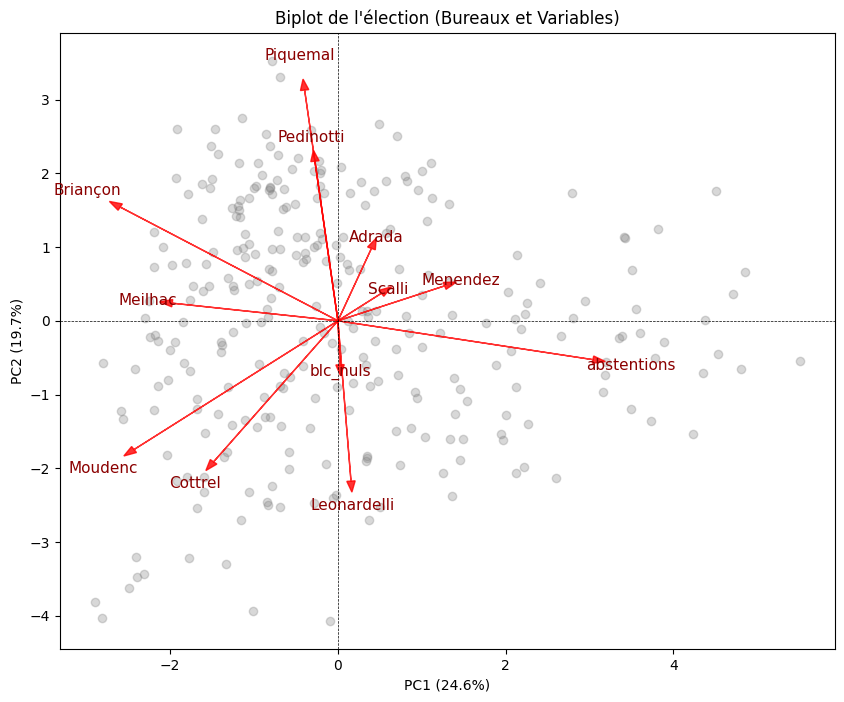

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')

plt.show()

In [ ]:
print(colonnes_totales[:-1])

Index(['abstentions', 'Briançon', 'Scalli', 'Adrada', 'Menendez', 'Moudenc',
       'Leonardelli', 'Cottrel', 'Meilhac', 'Piquemal', 'Pedinotti',
       'blc_nuls'],
      dtype='str')


In [ ]:
premier_tour['PC1'] = X_pca[:, 0]
premier_tour['PC2'] = X_pca[:, 1]

bureaux_extreme_droite_pc1 = premier_tour.nlargest(5, 'PC1')

bureaux_extreme_bas_pc2 = premier_tour.nsmallest(5, 'PC2')

colonnes_totales_analyse = colonnes_totales[:-1]

display(bureaux_extreme_droite_pc1[['bureau', 'PC1']])
display(bureaux_extreme_bas_pc2[['bureau', 'PC2']])


Index(['Tour', 'bureau', 'inscrits', 'abstentions', 'votants',
       'votants_ap_emargement', 'blancs', 'nuls', 'exprimes', 'Briançon',
       'Scalli', 'Adrada', 'Menendez', 'Moudenc', 'Leonardelli', 'Cottrel',
       'Meilhac', 'Piquemal', 'Pedinotti', 'adresse', 'Geo_Point', 'Geo_Shape',
       'gml_id', 'infobulle', 'oid', 'Nom', 'tx_participation', 'tx_nuls_blc',
       'PC1', 'PC2', 'Cluster'],
      dtype='str')
Index(['abstentions', 'Briançon', 'Scalli', 'Adrada', 'Menendez', 'Moudenc',
       'Leonardelli', 'Cottrel', 'Meilhac', 'Piquemal', 'Pedinotti'],
      dtype='str')


,bureau,PC1
134,0102,5.502648
78,0101,4.853543
198,0097,4.810274
196,0094,4.713333
132,0098,4.526769


,bureau,PC2
229,0252,-4.065985
272,0231,-4.031922
141,0147,-3.935380
227,0232,-3.813517
129,0063,-3.626621


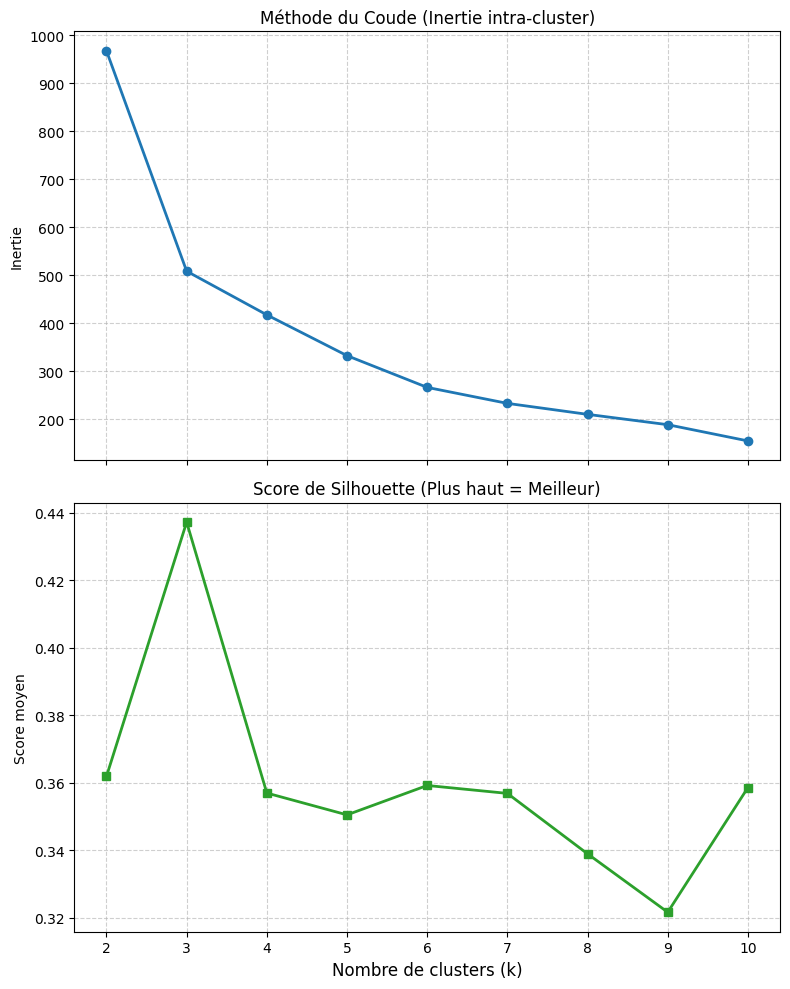

In [110]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [122]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

premier_tour['Cluster'] = labels_clusters

print("Nombre de bureaux par cluster :")
print(premier_tour['Cluster'].value_counts())

Nombre de bureaux par cluster :
Cluster
1    130
2     86
0     68
Name: count, dtype: int64


In [124]:
profils_clusters = premier_tour.groupby('Cluster')[colonnes_totales_analyse].mean()

display(profils_clusters.round(1))

,abstentions,Briançon,Scalli,Adrada,Menendez,Moudenc,Leonardelli,Cottrel,Meilhac,Piquemal,Pedinotti
Cluster,,,,,,,,,,,
0,544.0,75.4,1.6,2.0,1.4,124.3,31.3,4.7,5.0,119.2,4.4
1,402.9,171.5,1.7,2.9,1.0,202.4,23.8,5.9,10.9,198.7,7.3
2,383.7,137.5,1.3,1.7,0.7,275.5,37.4,10.0,10.4,108.6,4.3


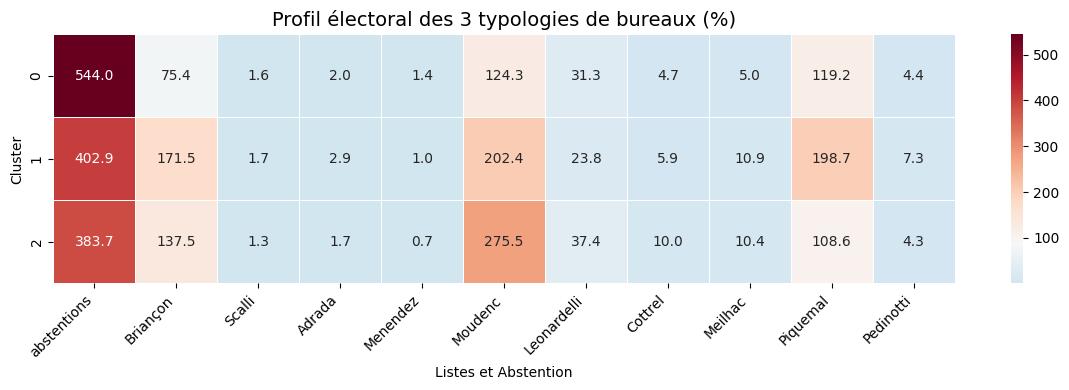

In [126]:
import seaborn as sns

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 3 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Analyse dynamique temporelle

In [193]:
df_fusion = pd.merge(premier_tour, deuxieme_tour, on = 'bureau')

In [194]:
print(df_fusion.columns)

Index(['Tour_x', 'bureau', 'inscrits_x', 'abstentions_x', 'votants_x',
       'votants_ap_emargement_x', 'blancs_x', 'nuls_x', 'exprimes_x',
       'Briançon', 'Scalli', 'Adrada', 'Menendez', 'Moudenc_x', 'Leonardelli',
       'Cottrel', 'Meilhac', 'Piquemal_x', 'Pedinotti', 'adresse_x',
       'Geo_Point_x', 'Geo_Shape_x', 'gml_id_x', 'infobulle_x', 'oid_x',
       'Nom_x', 'tx_participation_x', 'tx_nuls_blc_x', 'PC1', 'PC2', 'Cluster',
       'Tour_y', 'inscrits_y', 'abstentions_y', 'votants_y',
       'votants_ap_emargement_y', 'blancs_y', 'nuls_y', 'exprimes_y',
       'Moudenc_y', 'Piquemal_y', 'adresse_y', 'Geo_Point_y', 'Geo_Shape_y',
       'gml_id_y', 'infobulle_y', 'oid_y', 'Nom_y', 'tx_participation_y',
       'tx_nuls_blc_y'],
      dtype='str')


In [195]:
columns_fusion_name = ['Tour', 'bureau', 'inscrits_premier', 'abstentions_premier', 'votants_premier',
       'votants_ap_emargement_premier', 'blancs_premier', 'nuls_premier', 'exprimes_premier',
       'Briançon', 'Scalli', 'Adrada', 'Menendez', 'Moudenc_premier', 'Leonardelli',
       'Cottrel', 'Meilhac', 'Piquemal_premier', 'Pedinotti', 'adresse_premier',
       'Geo_Point_premier', 'Geo_Shape_premier', 'gml_id_premier', 'infobulle_premier', 'oid_premier',
       'Nom_premier', 'tx_participation_premier', 'tx_nuls_blc_premier', 'PC1_premier', 'PC2_premier', 'Cluster_premier',
       'Tour_second', 'inscrits_second', 'abstentions_second', 'votants_second',
       'votants_ap_emargement_second', 'blancs_second', 'nuls_second', 'exprimes_second',
       'Moudenc_second', 'Piquemal_second', 'adresse_second', 'Geo_Point_second', 'Geo_Shape_second',
       'gml_id_second', 'infobulle_second', 'oid_second', 'Nom_second', 'tx_participation_second',
       'tx_nuls_blc_second']

df_fusion.columns = columns_fusion_name

df_fusion['Delta_Abstention'] = df_fusion['abstentions_second'] - df_fusion['abstentions_premier']
df_fusion['blc_nuls_premier'] = df_fusion['blancs_premier'] + df_fusion['nuls_premier']
df_fusion['blc_nuls_second'] = df_fusion['blancs_second'] + df_fusion['nuls_second']
df_fusion['Delta_Gauche'] = df_fusion['Piquemal_second'] - (df_fusion['Briançon'] + df_fusion['Piquemal_premier'])

df_fusion_cleaned = df_fusion.drop(columns=['Tour', 'Tour_second', 'bureau', 'votants_ap_emargement_premier', 'votants_ap_emargement_second', 
                                    'adresse_premier', 'Geo_Point_premier', 
                                    'Geo_Shape_premier', 'gml_id_premier', 
                                    'infobulle_premier', 'oid_premier', 'exprimes_premier', 'exprimes_second', 
                                    'Nom_premier', 'tx_participation_premier', 
                                    'adresse_second', 'votants_premier', 'votants_second', 
                                    'Geo_Point_second', 'Geo_Shape_second','tx_nuls_blc_premier', 'tx_nuls_blc_second',
                                    'gml_id_second', 'infobulle_second', 'blancs_premier', 'nuls_premier', 'blancs_second', 'nuls_second',
                                    'oid_second', 'Nom_second', 'tx_participation_second'])

print(df_fusion_cleaned.columns)

Index(['inscrits_premier', 'abstentions_premier', 'Briançon', 'Scalli',
       'Adrada', 'Menendez', 'Moudenc_premier', 'Leonardelli', 'Cottrel',
       'Meilhac', 'Piquemal_premier', 'Pedinotti', 'PC1_premier',
       'PC2_premier', 'Cluster_premier', 'inscrits_second',
       'abstentions_second', 'Moudenc_second', 'Piquemal_second',
       'Delta_Abstention', 'blc_nuls_premier', 'blc_nuls_second',
       'Delta_Gauche'],
      dtype='str')


In [180]:
display(df_fusion_cleaned.head())

,inscrits_premier,abstentions_premier,blancs_premier,nuls_premier,Briançon,Scalli,Adrada,Menendez,Moudenc_premier,Leonardelli,...,PC2_premier,Cluster_premier,inscrits_second,abstentions_second,blancs_second,nuls_second,Moudenc_second,Piquemal_second,Delta_Abstention,Delta_Gauche
0,957,401,4,2,121,0,1,3,185,13,...,1.753374,1,956,335,15,4,292,310,-66,-19
1,892,384,2,1,98,0,1,0,233,15,...,-0.915855,2,892,283,5,0,373,231,-101,-1
2,1159,513,3,3,165,2,8,2,173,27,...,1.770610,1,1159,435,18,8,292,406,-78,-4
3,1131,362,3,1,223,0,2,0,276,8,...,1.938102,1,1131,286,18,4,416,407,-76,-45
4,781,328,4,2,126,0,2,0,146,30,...,-0.580932,2,781,282,10,5,248,236,-46,-12


In [196]:
listes_candidates_premier = df_fusion_cleaned.columns[1:11]
listes_candidates_second = df_fusion_cleaned.columns[16:19]

print(listes_candidates_premier)
print(listes_candidates_second)

df_fusion_cleaned[listes_candidates_premier] = df_fusion_cleaned[listes_candidates_premier].div(df_fusion_cleaned['inscrits_premier'], axis=0) * 100
df_fusion_cleaned[listes_candidates_second] = df_fusion_cleaned[listes_candidates_second].div(df_fusion_cleaned['inscrits_second'], axis=0) * 100
df_fusion_cleaned['blc_nuls_premier'] = df_fusion_cleaned['blc_nuls_premier'] /df_fusion_cleaned['inscrits_premier'] *100
df_fusion_cleaned['blc_nuls_second'] = df_fusion_cleaned['blc_nuls_second'] /df_fusion_cleaned['inscrits_second'] *100

df_fusion_cleaned = df_fusion_cleaned.drop(columns=['inscrits_premier', 'inscrits_second', 'PC1_premier', 'PC2_premier', 'Cluster_premier'])

Index(['abstentions_premier', 'Briançon', 'Scalli', 'Adrada', 'Menendez',
       'Moudenc_premier', 'Leonardelli', 'Cottrel', 'Meilhac',
       'Piquemal_premier'],
      dtype='str')
Index(['abstentions_second', 'Moudenc_second', 'Piquemal_second'], dtype='str')


In [183]:
display(df_fusion_cleaned.head())

,abstentions_premier,Briançon,Scalli,Adrada,Menendez,Moudenc_premier,Leonardelli,Cottrel,Meilhac,Piquemal_premier,Pedinotti,abstentions_second,Moudenc_second,Piquemal_second,Delta_Abstention,Delta_Gauche,blc_nuls_premier,blc_nuls_second
0,41.901776,12.643678,0.000000,0.104493,0.313480,19.331243,1.358412,0.313480,0.940439,21.734587,7,35.041841,30.543933,32.426778,-66,-19,0.626959,1.987448
1,43.049327,10.986547,0.000000,0.112108,0.000000,26.121076,1.681614,1.681614,0.224215,15.022422,7,31.726457,41.816143,25.896861,-101,-1,0.336323,0.560538
2,44.262295,14.236411,0.172563,0.690250,0.172563,14.926661,2.329594,0.517688,0.517688,21.138913,6,37.532355,25.194133,35.030198,-78,-4,0.517688,2.243313
3,32.007073,19.717065,0.000000,0.176835,0.000000,24.403183,0.707339,0.618921,0.884173,20.247569,10,25.287356,36.781609,35.985853,-76,-45,0.353669,1.945181
4,41.997439,16.133163,0.000000,0.256082,0.000000,18.693982,3.841229,1.152369,1.024328,15.620999,4,36.107554,31.754161,30.217670,-46,-12,0.768246,1.920615


Variance expliquée par axe : [32.06769995 20.05697826]


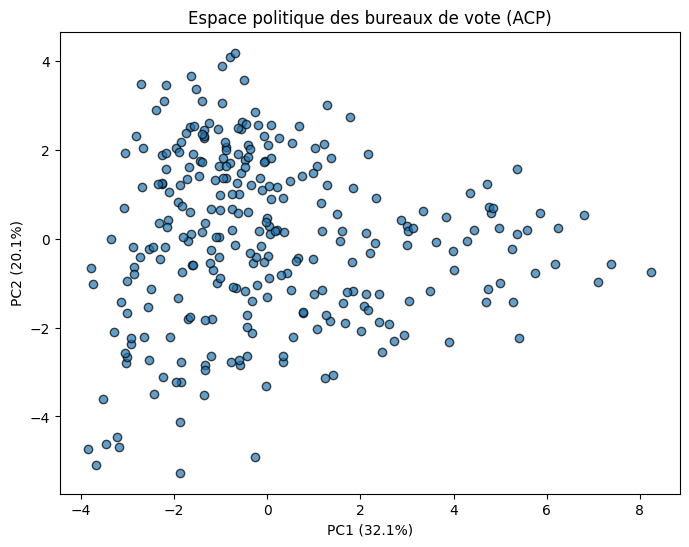

In [197]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_fusion_cleaned)

pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par axe : {pca.explained_variance_ratio_ * 100}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Espace politique des bureaux de vote (ACP)')
plt.show()

In [198]:
colonnes_totales = df_fusion_cleaned.columns

df_loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=colonnes_totales  
)

print("--- Contributions à l'axe PC1 ---")
display(df_loadings.sort_values(by='PC1', ascending=False)['PC1'])

print("\n--- Contributions à l'axe PC2 ---")
display(df_loadings.sort_values(by='PC2', ascending=False)['PC2'])

--- Contributions à l'axe PC1 ---


abstentions_premier    0.403369
abstentions_second     0.403182
Delta_Gauche           0.366306
Menendez               0.126833
Delta_Abstention       0.070795
Scalli                 0.056284
Adrada                 0.030619
Leonardelli            0.003847
blc_nuls_premier      -0.009906
Piquemal_premier      -0.045076
Pedinotti             -0.064491
Piquemal_second       -0.088641
Cottrel               -0.183306
Meilhac               -0.225320
blc_nuls_second       -0.280056
Moudenc_premier       -0.327424
Moudenc_second        -0.339179
Briançon              -0.340796
Name: PC1, dtype: float64


--- Contributions à l'axe PC2 ---


Piquemal_second        0.494874
Piquemal_premier       0.483796
Pedinotti              0.278435
Briançon               0.238581
Delta_Abstention       0.134234
blc_nuls_second        0.127181
Adrada                 0.120058
Menendez               0.063211
Scalli                 0.056288
Meilhac                0.038489
Delta_Gauche           0.022771
abstentions_second    -0.056396
blc_nuls_premier      -0.067492
abstentions_premier   -0.084153
Cottrel               -0.261737
Moudenc_premier       -0.272188
Moudenc_second        -0.284786
Leonardelli           -0.300516
Name: PC2, dtype: float64

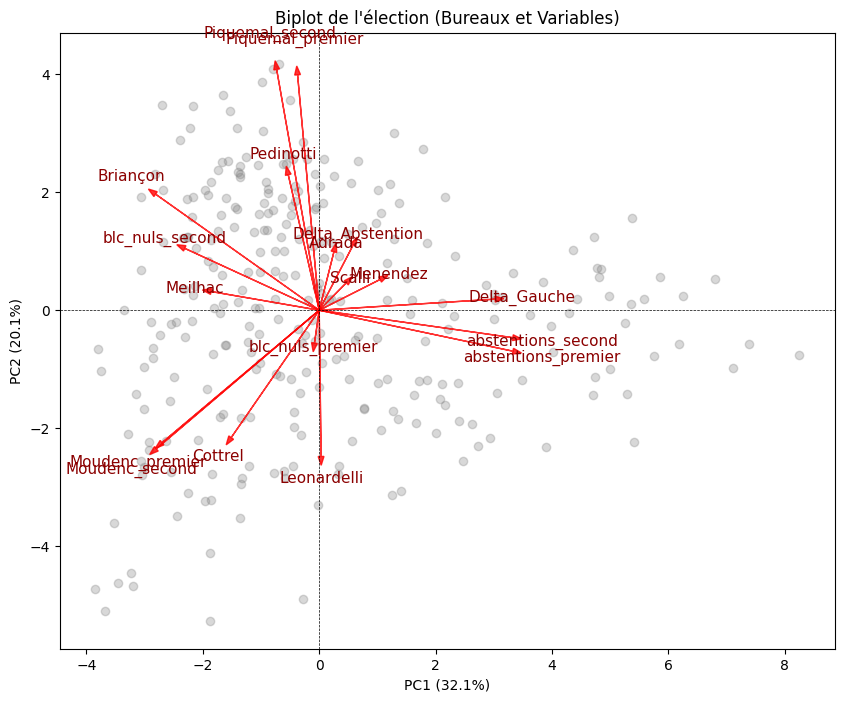

In [199]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, color='grey')

poids_pc1 = pca.components_[0]
poids_pc2 = pca.components_[1]

scale = np.max(np.abs(X_pca)) 

for i, variable in enumerate(colonnes_totales):
    ax.arrow(0, 0, poids_pc1[i] * scale, poids_pc2[i] * scale, 
             color='red', alpha=0.8, head_width=0.1)
    
    ax.text(poids_pc1[i] * scale * 1.15, poids_pc2[i] * scale * 1.15, 
            variable, color='darkred', ha='center', va='center', fontsize=11)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Biplot de l\'élection (Bureaux et Variables)')

plt.show()

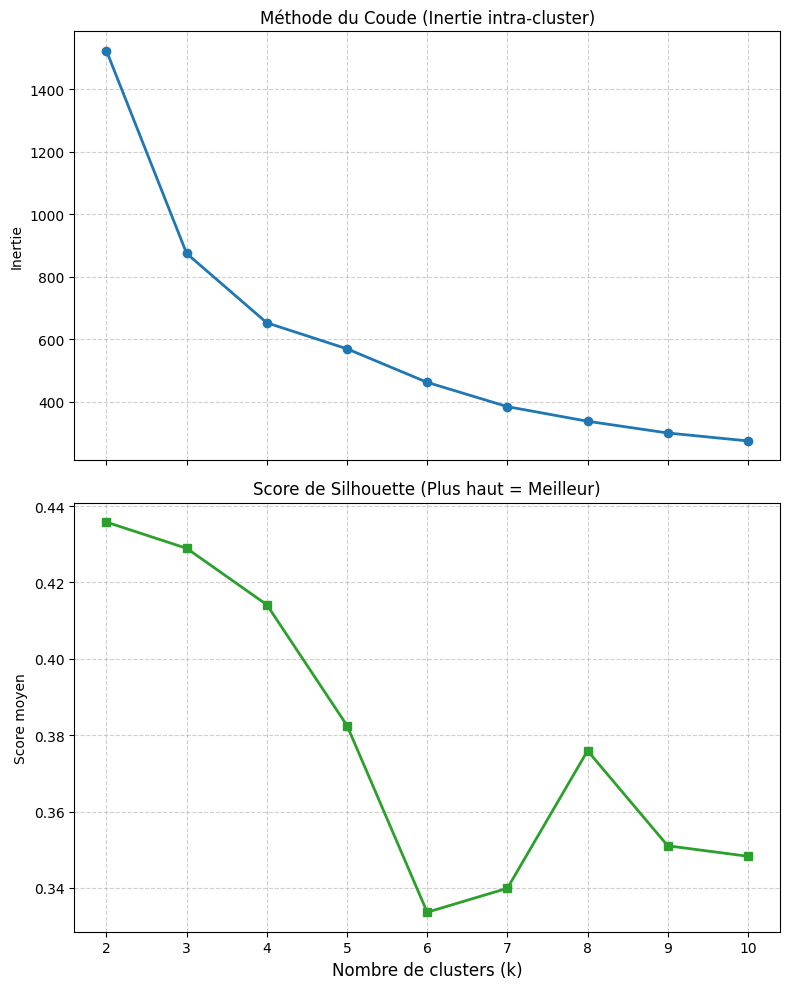

In [200]:
k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    kmeans.fit(X_pca) 
    
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), sharex=True)

ax1.plot(k_range, inertias, marker='o', linewidth=2, color='tab:blue')
ax1.set_title('Méthode du Coude (Inertie intra-cluster)', fontsize=12)
ax1.set_ylabel('Inertie')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, color='tab:green')
ax2.set_title('Score de Silhouette (Plus haut = Meilleur)', fontsize=12)
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [201]:
df_fusion['PC1'] = X_pca[:, 0]
df_fusion['PC2'] = X_pca[:, 1]

bureaux_extreme_droite_pc1 = df_fusion.nlargest(5, 'PC1')

bureaux_extreme_bas_pc2 = df_fusion.nsmallest(5, 'PC2')

colonnes_totales_analyse = colonnes_totales[:-1]

display(bureaux_extreme_droite_pc1[['bureau', 'PC1']])
display(bureaux_extreme_bas_pc2[['bureau', 'PC2']])

,bureau,PC1
134,0102,8.250695
132,0098,7.387652
198,0097,7.104439
78,0101,6.801594
14,0071,6.245987


,bureau,PC2
141,0147,-5.264590
272,0231,-5.099903
229,0252,-4.902005
227,0232,-4.724380
271,0229,-4.678385


In [ ]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

df_fusion['Cluster'] = labels_clusters

print("Nombre de bureaux par cluster :")
print(df_fusion['Cluster'].value_counts())

profils_clusters = df_fusion.groupby('Cluster')[colonnes_totales_analyse].mean()
display(profils_clusters.round(1))

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 3 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Nombre de bureaux par cluster :
Cluster
1    125
2     92
0     67
Name: count, dtype: int64


Nombre de bureaux par cluster :
Cluster
1    52
2    48
0    43
6    39
5    32
4    31
7    30
3     9
Name: count, dtype: int64


,abstentions_premier,Briançon,Scalli,Adrada,Menendez,Moudenc_premier,Leonardelli,Cottrel,Meilhac,Piquemal_premier,Pedinotti,abstentions_second,Moudenc_second,Piquemal_second,Delta_Abstention,blc_nuls_premier,blc_nuls_second
Cluster,,,,,,,,,,,,,,,,,
0,513.9,106.6,1.6,2.2,0.9,193.9,49.9,8.0,9.5,112.7,4.8,452.3,331.2,213.6,-61.5,7.4,14.3
1,387.0,199.2,1.5,2.5,1.1,212.5,22.1,6.6,11.3,232.4,8.2,329.0,334.1,405.1,-58.0,7.9,24.2
2,360.0,162.4,1.3,2.1,0.5,250.1,28.6,8.8,11.1,143.3,5.2,298.1,389.1,273.6,-61.8,7.1,19.8
3,682.7,37.1,0.8,1.3,1.0,73.1,12.4,2.2,1.4,121.7,2.3,605.1,106.7,222.6,-77.6,4.2,5.8
4,493.1,60.9,1.4,1.8,1.7,91.2,23.5,3.4,3.2,113.4,4.0,445.3,150.0,200.0,-47.7,6.1,8.3
5,351.4,128.3,0.9,1.3,0.7,339.3,33.0,11.4,9.3,86.3,3.1,278.7,495.7,180.7,-72.7,7.2,17.4
6,435.9,151.6,1.8,2.2,1.1,175.3,21.5,4.9,11.4,193.1,6.9,380.0,281.9,332.8,-55.9,4.7,15.7
7,440.2,142.3,2.6,4.4,1.4,196.2,34.7,5.4,8.6,152.0,7.2,383.4,313.0,285.6,-56.8,8.0,20.7


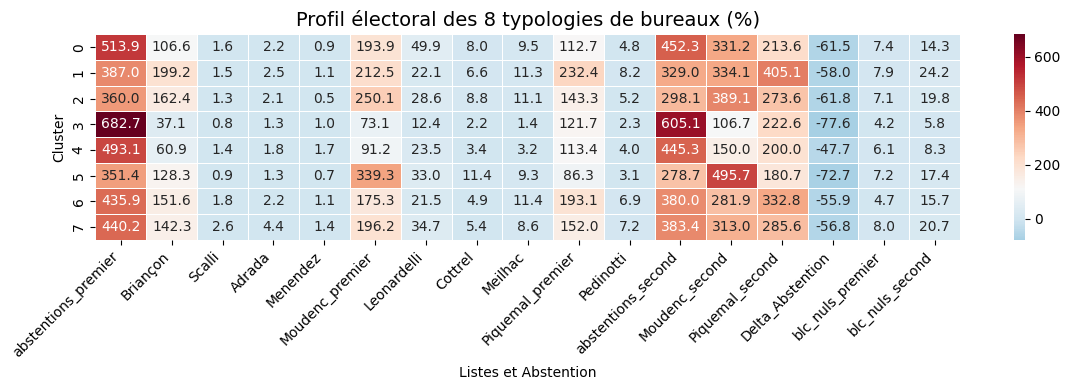

In [206]:
kmeans_final = KMeans(n_clusters=8, random_state=42, n_init='auto')

labels_clusters = kmeans_final.fit_predict(X_scaled)

df_fusion['Cluster'] = labels_clusters

print("Nombre de bureaux par cluster :")
print(df_fusion['Cluster'].value_counts())

profils_clusters = df_fusion.groupby('Cluster')[colonnes_totales_analyse].mean()
display(profils_clusters.round(1))

plt.figure(figsize=(12, 4)) 

sns.heatmap(profils_clusters, annot=True, cmap='RdBu_r', center=profils_clusters.mean().mean(), fmt=".1f", linewidths=.5)

plt.title('Profil électoral des 8 typologies de bureaux (%)', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Listes et Abstention')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()